In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


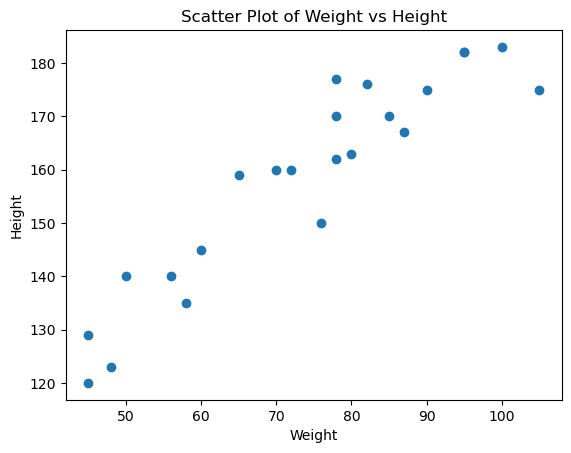

In [4]:
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Scatter Plot of Weight vs Height")
plt.show()

In [12]:
#divide the feature based on independent and dependent 
# train test split
X=df[["Weight"]]  #independent feature
y=df["Height"] 

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train.values.reshape(-1,1))# here fit will compute the mean and standard deviation of the training data and transform will apply the  z score formula on data
X_test_scaled=scaler.transform(X_test.values.reshape(-1,1))  # here we will only transform the test data using the mean and standard deviation computed from the training data due to data leakage# here fit will compute the mean and standard deviation of the training data and transform will apply the  z score formula on data


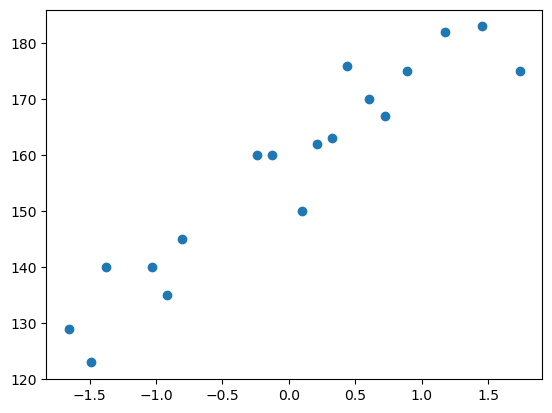

In [15]:
plt.scatter(X_train_scaled,y_train)

In [16]:
# train the model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train_scaled,y_train)


LinearRegression()

In [17]:
regressor.coef_

array([17.03440872])

In [18]:
regressor.intercept_

np.float64(157.5)

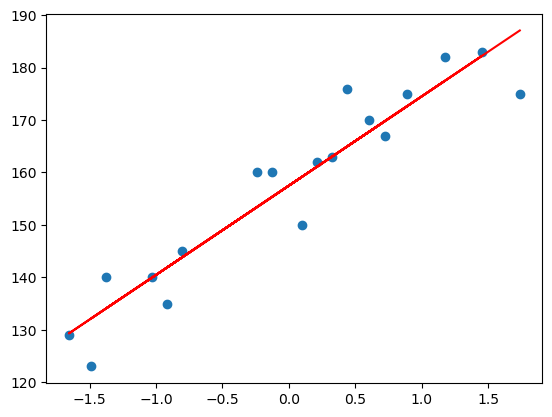

In [19]:
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,regressor.predict(X_train_scaled),color="red")

In [20]:
# PREDICTION OF TEST DATA
y_pred=regressor.predict(X_test_scaled)
y_pred

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

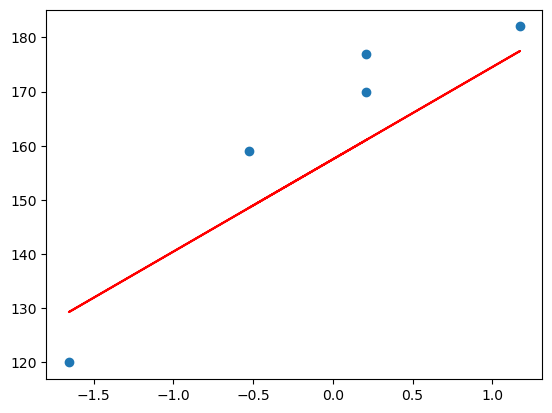

In [21]:
plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled,y_pred,color="red")

In [22]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred) 
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae) # ass this value is decreseing that means your model is performing much better
print("R-squared Score:",r2)
print("Root Mean Squared Error:",rmse)

Mean Squared Error: 109.77592599051654
Mean Absolute Error: 9.822657814519227
R-squared Score: 0.7769869860423441
Root Mean Squared Error: 10.477400726827076


In [24]:
#whenever you getting new data point
# first standardization then prediction
scaled_weight=scaler.transform([[80]])
regressor.predict([scaled_weight[0]])

array([163.01076266])

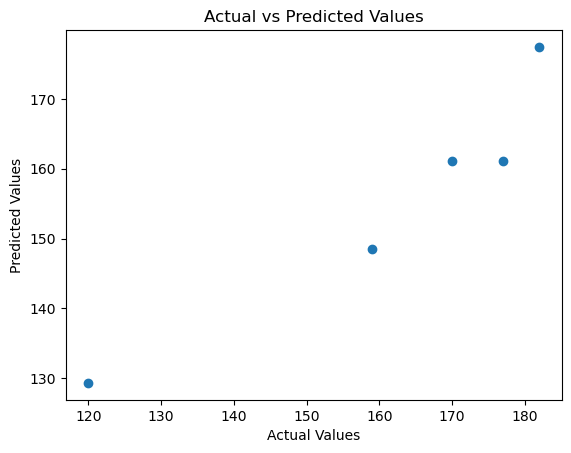

In [25]:
#assumption
#plot thescatter plot for the prediction
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [26]:
residuals=y_test-y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

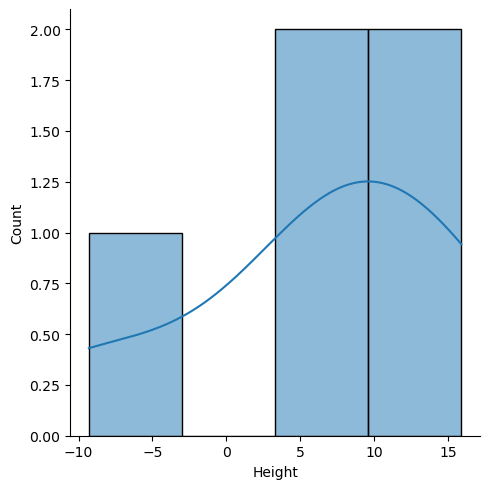

In [27]:
sns.displot(residuals, kde=True)

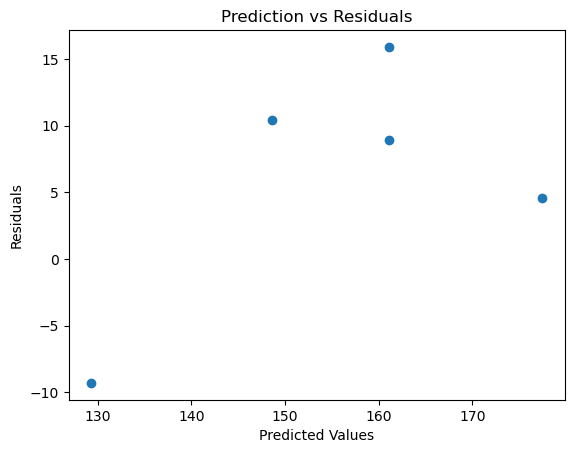

In [28]:
# scatter plot of prediction vs residuals
# should be uniform distribution then this is very good model
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Prediction vs Residuals")
plt.show()